EXPERIMENT 11
Policy Gradient Implementation using REINFORCE Algorithm
Episode: 25 | Reward: 30.0 | Loss: -0.001 | Entropy: 0.6925
Episode: 50 | Reward: 20.0 | Loss: -0.0396 | Entropy: 0.6763
Episode: 75 | Reward: 10.0 | Loss: 0.1963 | Entropy: 0.6219
Episode: 100 | Reward: 20.0 | Loss: 0.0141 | Entropy: 0.6295
Episode: 125 | Reward: 36.0 | Loss: 0.0192 | Entropy: 0.6337
Episode: 150 | Reward: 86.0 | Loss: -0.0539 | Entropy: 0.6392


SAMPLE DATASET


,Episode,Reward,Policy_Loss,Entropy,Episode_Length,Action_0_Probability,Action_1_Probability
0,1,44.0,0.004537,0.688393,44,0.528647,0.471353
1,2,29.0,0.006163,0.693081,29,0.499560,0.500440
2,3,18.0,-0.001356,0.693076,18,0.495016,0.504984
3,4,13.0,-0.013295,0.692442,13,0.482458,0.517542
4,5,34.0,-0.000236,0.692189,34,0.501077,0.498923
5,6,31.0,0.000462,0.692267,31,0.510055,0.489945
6,7,26.0,0.003908,0.691056,26,0.471918,0.528082
7,8,21.0,-0.012060,0.689101,21,0.458233,0.541767
8,9,17.0,0.030130,0.689254,17,0.461482,0.538518
9,10,22.0,-0.013261,0.690550,22,0.468066,0.531934


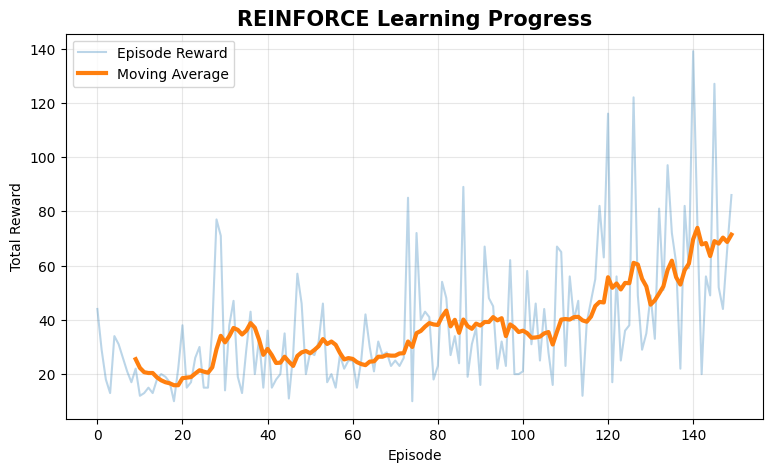

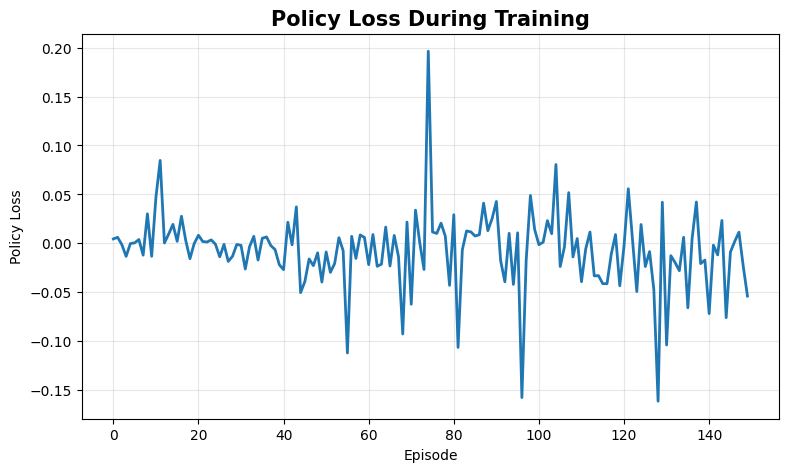

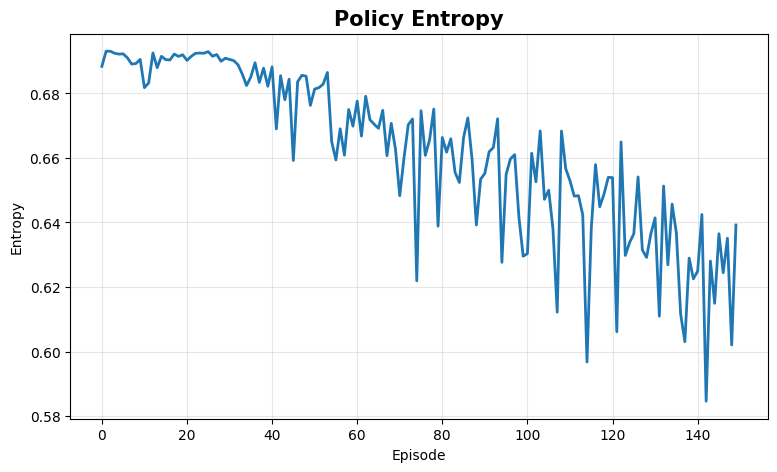

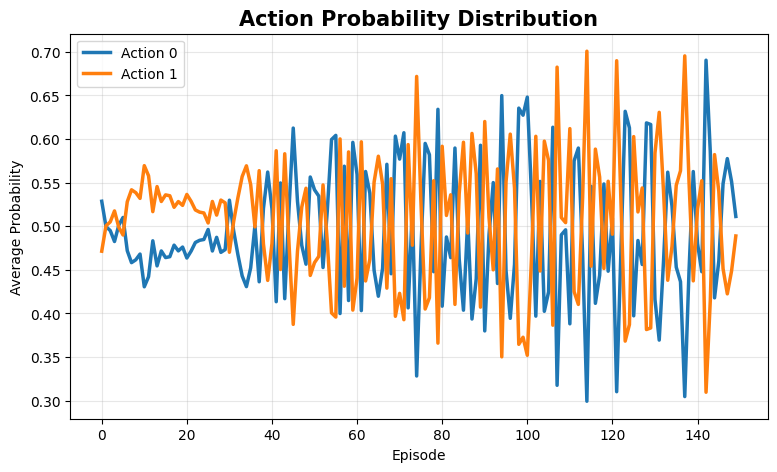

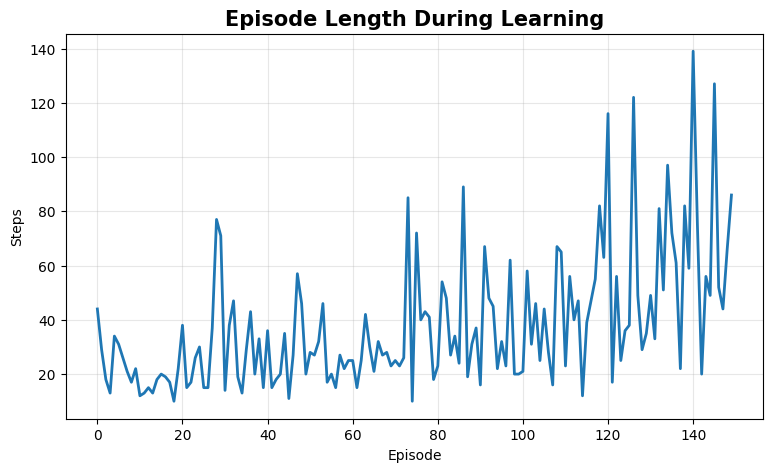



SUMMARY TABLE


,Metric,Result
0,Algorithm,REINFORCE
1,Environment,CartPole-v1
2,Episodes,150
3,Initial Average Reward,21.6
4,Final Average Reward,63.76
5,Maximum Reward,139.0
6,Final Reward Variance,1009.19
7,Average Episode Length,63.76




FINAL RESULT
Initial Average Reward: 21.6
Final Average Reward: 63.76
Maximum Reward: 139.0
Final Reward Variance: 1009.19
Average Episode Length: 63.76


CONCLUSION
The REINFORCE policy gradient algorithm was successfully
implemented using TensorFlow and Keras.
The policy directly learned action probabilities from
complete episode rewards.
The learning curve, policy loss, entropy, action
probabilities and episode length were analyzed.
The final reward was compared with the initial reward
to evaluate the learning performance.

Generated Files:
REINFORCE_Full_Dataset.csv
REINFORCE_Summary.csv

Experiment 11 Completed Successfully.


In [1]:
!pip -q install gymnasium tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("EXPERIMENT 11")
print("Policy Gradient Implementation using REINFORCE Algorithm")
print("="*70)

env=gym.make("CartPole-v1")

state_size=4
action_size=2
episodes=150
gamma=0.99
learning_rate=0.001

model=Sequential([
    Input(shape=(state_size,)),
    Dense(64,activation="relu"),
    Dense(64,activation="relu"),
    Dense(action_size,activation="softmax")
])

optimizer=Adam(learning_rate=learning_rate)

def select_action(state):
    state=np.array([state],dtype=np.float32)
    probabilities=model(state,training=False).numpy()[0]
    action=np.random.choice(action_size,p=probabilities)
    return action,probabilities

def calculate_returns(rewards):
    returns=[]
    total=0

    for reward in reversed(rewards):
        total=reward+gamma*total
        returns.insert(0,total)

    returns=np.array(returns,dtype=np.float32)

    if len(returns)>1:
        returns=(returns-np.mean(returns))/(np.std(returns)+1e-8)

    return returns

reward_history=[]
loss_history=[]
entropy_history=[]
length_history=[]
action0_history=[]
action1_history=[]

for episode in range(episodes):

    state,_=env.reset()

    states=[]
    actions=[]
    rewards=[]
    probabilities=[]

    done=False

    while not done:

        action,probs=select_action(state)

        next_state,reward,terminated,truncated,_=env.step(action)

        done=terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        probabilities.append(probs)

        state=next_state

    returns=calculate_returns(rewards)

    states_tensor=tf.convert_to_tensor(
        np.array(states),
        dtype=tf.float32
    )

    actions_tensor=tf.convert_to_tensor(
        np.array(actions),
        dtype=tf.int32
    )

    returns_tensor=tf.convert_to_tensor(
        returns,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        action_probs=model(
            states_tensor,
            training=True
        )

        selected_probs=tf.gather(
            action_probs,
            actions_tensor,
            axis=1,
            batch_dims=1
        )

        log_probs=tf.math.log(
            selected_probs+1e-8
        )

        policy_loss=-tf.reduce_mean(
            log_probs*returns_tensor
        )

        entropy=-tf.reduce_mean(
            tf.reduce_sum(
                action_probs*tf.math.log(
                    action_probs+1e-8
                ),
                axis=1
            )
        )

        total_loss=policy_loss-0.01*entropy

    gradients=tape.gradient(
        total_loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    avg_probs=np.mean(
        probabilities,
        axis=0
    )

    reward_history.append(
        np.sum(rewards)
    )

    loss_history.append(
        float(policy_loss.numpy())
    )

    entropy_history.append(
        float(entropy.numpy())
    )

    length_history.append(
        len(rewards)
    )

    action0_history.append(
        avg_probs[0]
    )

    action1_history.append(
        avg_probs[1]
    )

    if (episode+1)%25==0:
        print(
            "Episode:",
            episode+1,
            "| Reward:",
            round(reward_history[-1],2),
            "| Loss:",
            round(loss_history[-1],4),
            "| Entropy:",
            round(entropy_history[-1],4)
        )

env.close()

dataset=pd.DataFrame({
    "Episode":range(1,episodes+1),
    "Reward":reward_history,
    "Policy_Loss":loss_history,
    "Entropy":entropy_history,
    "Episode_Length":length_history,
    "Action_0_Probability":action0_history,
    "Action_1_Probability":action1_history
})

print("\n")
print("="*70)
print("SAMPLE DATASET")
print("="*70)

display(dataset.head(10))

dataset.to_csv(
    "REINFORCE_Full_Dataset.csv",
    index=False
)

reward_smooth=dataset["Reward"].rolling(10).mean()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Reward"],
    alpha=0.3,
    label="Episode Reward"
)

plt.plot(
    reward_smooth,
    linewidth=3,
    label="Moving Average"
)

plt.title(
    "REINFORCE Learning Progress",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Policy_Loss"],
    linewidth=2
)

plt.title(
    "Policy Loss During Training",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Policy Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Entropy"],
    linewidth=2
)

plt.title(
    "Policy Entropy",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Entropy")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Action_0_Probability"],
    label="Action 0",
    linewidth=2.5
)

plt.plot(
    dataset["Action_1_Probability"],
    label="Action 1",
    linewidth=2.5
)

plt.title(
    "Action Probability Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))

plt.plot(
    dataset["Episode_Length"],
    linewidth=2
)

plt.title(
    "Episode Length During Learning",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(alpha=0.3)
plt.show()

initial_reward=dataset["Reward"].head(25).mean()
final_reward=dataset["Reward"].tail(25).mean()
maximum_reward=dataset["Reward"].max()
reward_variance=dataset["Reward"].tail(25).var()
average_length=dataset["Episode_Length"].tail(25).mean()

summary=pd.DataFrame({
    "Metric":[
        "Algorithm",
        "Environment",
        "Episodes",
        "Initial Average Reward",
        "Final Average Reward",
        "Maximum Reward",
        "Final Reward Variance",
        "Average Episode Length"
    ],
    "Result":[
        "REINFORCE",
        "CartPole-v1",
        episodes,
        round(initial_reward,2),
        round(final_reward,2),
        round(maximum_reward,2),
        round(reward_variance,2),
        round(average_length,2)
    ]
})

print("\n")
print("="*70)
print("SUMMARY TABLE")
print("="*70)

display(summary)

summary.to_csv(
    "REINFORCE_Summary.csv",
    index=False
)

print("\n")
print("="*70)
print("FINAL RESULT")
print("="*70)

print(
    "Initial Average Reward:",
    round(initial_reward,2)
)

print(
    "Final Average Reward:",
    round(final_reward,2)
)

print(
    "Maximum Reward:",
    round(maximum_reward,2)
)

print(
    "Final Reward Variance:",
    round(reward_variance,2)
)

print(
    "Average Episode Length:",
    round(average_length,2)
)

print("\n")
print("="*70)
print("CONCLUSION")
print("="*70)

print(
    "The REINFORCE policy gradient algorithm was successfully"
)

print(
    "implemented using TensorFlow and Keras."
)

print(
    "The policy directly learned action probabilities from"
)

print(
    "complete episode rewards."
)

print(
    "The learning curve, policy loss, entropy, action"
)

print(
    "probabilities and episode length were analyzed."
)

print(
    "The final reward was compared with the initial reward"
)

print(
    "to evaluate the learning performance."
)

print("\nGenerated Files:")
print("REINFORCE_Full_Dataset.csv")
print("REINFORCE_Summary.csv")

print("\nExperiment 11 Completed Successfully.")